In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

afmir_data_folder = Path("afmir_data")

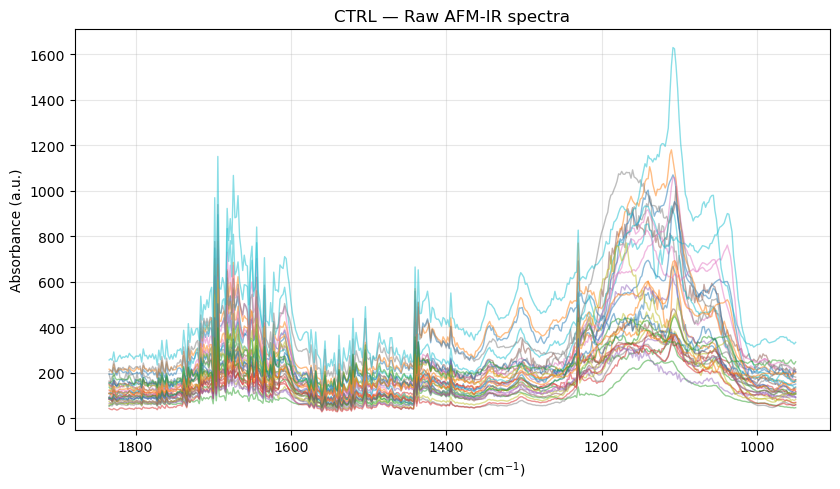

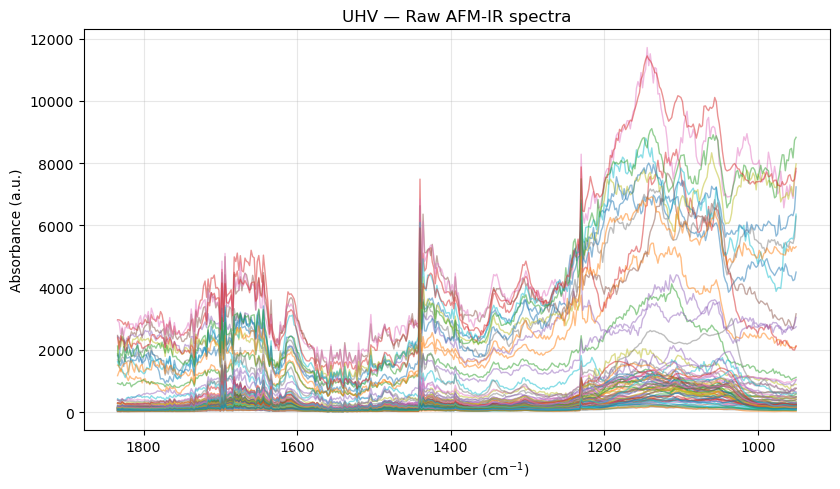

In [ ]:
# Filenames grouped by sample
FILE_GROUPS = {
    "ctrl": ["AMP_thicklayer_ctrl.csv", "AMP_thicklayer_ctrl_rep.csv"],
    "uhv":  ["AMP_thicklayer_UHV.csv",  "AMP_thicklayer_UHV_rep.csv"],
}

# Column naming and plotting conventions
X_NAME = "wavenumber_cm-1"
Y_UNITS = "Absorbance (a.u.)"
INVERT_X_AXIS = True   # IR convention

# CSV reading options
CSV_KW = dict(sep=",", decimal=".", header=0)  # adjust decimal="," if needed

# ------------- Helper functions -------------

def load_afmir_csv(csv_path: Path, x_name: str = X_NAME) -> pd.DataFrame:
    """
    Load one AFM-IR CSV. First column -> wavenumber (index). Remaining columns -> spectra.
    Columns are renamed with file stem for uniqueness.
    """
    df = pd.read_csv(csv_path, **CSV_KW)
    if df.shape[1] < 2:
        raise ValueError(f"{csv_path.name}: expected ≥2 columns (x + spectra).")

    # Rename first column to standardized x_name and set as index
    original_x = df.columns[0]
    df = df.rename(columns={original_x: x_name})
    df = df.dropna(subset=[x_name]).sort_values(x_name)
    df = df.set_index(x_name)

    # Prefix spectrum columns with file stem to avoid name collisions
    stem = csv_path.stem
    renamed = {col: f"{stem}_{col}" for col in df.columns}
    df = df.rename(columns=renamed)

    # Enforce numeric type
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


def merge_group(csv_paths, x_name: str = X_NAME) -> pd.DataFrame:
    """
    Merge multiple CSVs (same sample) into one DataFrame (columns are individual spectra).
    If x-grids differ, reindex to the union and interpolate along x to align.
    """
    dfs = [load_afmir_csv(p, x_name=x_name) for p in csv_paths]

    # If all indexes are identical, fast concat
    same_index = all(dfs[0].index.equals(d.index) for d in dfs[1:])
    if same_index:
        merged = pd.concat(dfs, axis=1)
        merged.index.name = x_name
        return merged

    # Otherwise: align by interpolating to a common (union) grid
    common_index = dfs[0].index
    for d in dfs[1:]:
        common_index = common_index.union(d.index)
    common_index = common_index.sort_values()

    aligned = []
    for d in dfs:
        # reindex to union grid and interpolate along the x-index
        r = d.reindex(common_index).interpolate(method="index", limit_direction="both")
        # In case leading/trailing NaNs remain after interpolation
        r = r.fillna(method="ffill").fillna(method="bfill")
        aligned.append(r)

    merged = pd.concat(aligned, axis=1)
    merged.index.name = x_name
    return merged


def plot_group(df: pd.DataFrame, title: str, y_label: str = Y_UNITS, invert_x: bool = INVERT_X_AXIS):
    """Plot all spectra (each column) for one sample."""
    plt.figure(figsize=(8.5, 5.0))
    x = df.index.values
    for col in df.columns:
        plt.plot(x, df[col].values, lw=1.0, alpha=0.5)
    if invert_x:
        plt.gca().invert_xaxis()
    plt.title(title)
    plt.xlabel("Wavenumber (cm$^{-1}$)")
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()


# ------------- Load and merge by sample -------------

group_dfs = {}
for group, fnames in FILE_GROUPS.items():
    paths = [afmir_data_folder / f for f in fnames]
    group_dfs[group] = merge_group(paths, x_name=X_NAME)

# ------------- Plot RAW spectra -------------

plot_group(group_dfs["ctrl"], title="CTRL — Raw AFM-IR spectra")
plot_group(group_dfs["uhv"],  title="UHV — Raw AFM-IR spectra")
plt.show()


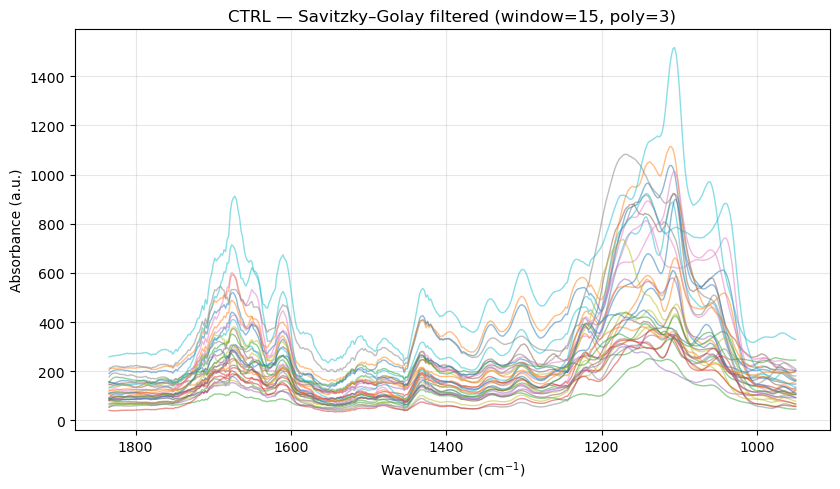

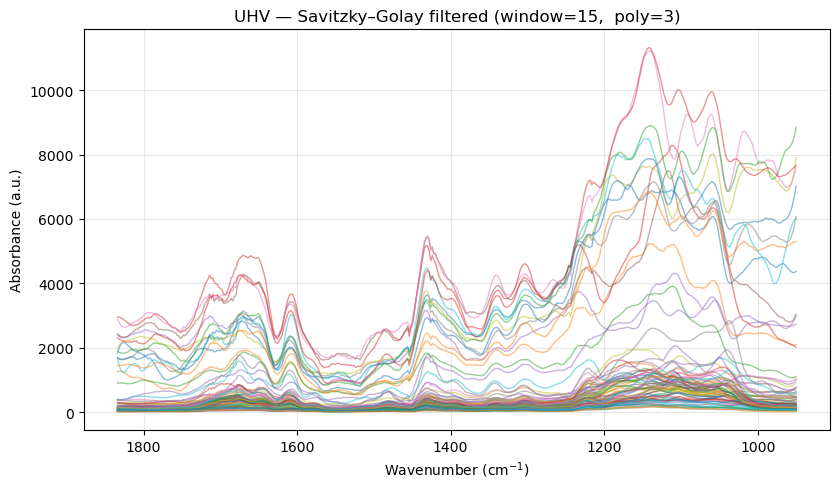

In [5]:
# === Savitzky–Golay smoothing ===

# Parameters (tune as needed)
SG_POLYORDER = 3
SG_WINDOW = 15  # must be odd and <= number of x points; code adapts if needed

def _effective_window(n: int, desired: int, poly: int) -> int:
    """
    Return a valid odd window length <= n and > poly.
    Minimally adjusts to satisfy constraints.
    """
    # Upper bound by n (and keep odd)
    w = min(desired, n if n % 2 == 1 else n - 1)
    # Make odd
    if w % 2 == 0:
        w -= 1
    # Ensure > poly
    if w <= poly:
        # smallest odd > poly
        w = poly + 2 if (poly + 2) % 2 == 1 else poly + 3
        # still must be <= n and odd
        if w > (n if n % 2 == 1 else n - 1):
            raise ValueError(f"Not enough points ({n}) for poly={poly}.")
    return w

def savgol_df(df: pd.DataFrame, poly: int = SG_POLYORDER, window: int = SG_WINDOW) -> tuple[pd.DataFrame, int]:
    """
    Apply Savitzky–Golay to every spectrum (each column). Returns (filtered_df, used_window).
    """
    n = len(df.index)
    w = _effective_window(n, window, poly)
    filtered = df.apply(lambda s: savgol_filter(s.values, window_length=w, polyorder=poly), axis=0, result_type="expand")
    filtered.index = df.index
    filtered.columns = df.columns
    return filtered, w

filtered_dfs = {}
used_windows = {}
for group, df in group_dfs.items():
    fdf, w = savgol_df(df, poly=SG_POLYORDER, window=SG_WINDOW)
    filtered_dfs[group] = fdf
    used_windows[group] = w

# Plot FILTERED spectra
plot_group(filtered_dfs["ctrl"], title=f"CTRL — Savitzky–Golay filtered (window={used_windows['ctrl']}, poly={SG_POLYORDER})")
plot_group(filtered_dfs["uhv"],  title=f"UHV — Savitzky–Golay filtered (window={used_windows['uhv']},  poly={SG_POLYORDER})")
plt.show()

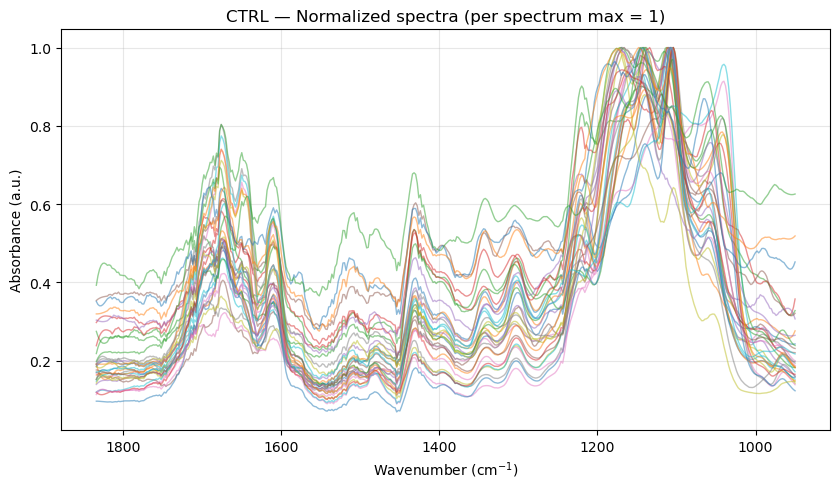

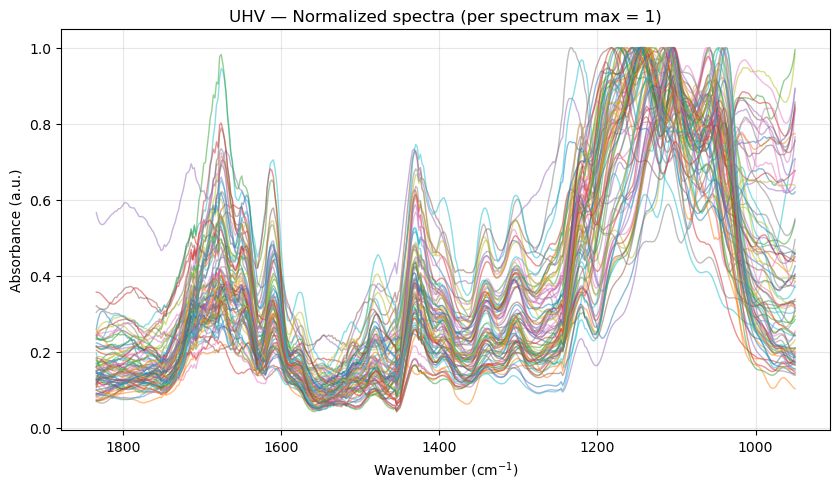

In [7]:
# === Normalization to unit max (per spectrum/column) ===
# By default we normalize the FILTERED spectra; switch to RAW by changing the source below.

NORMALIZE_FROM_FILTERED = True
norm_source = filtered_dfs if NORMALIZE_FROM_FILTERED else group_dfs

# Small epsilon to avoid division by zero in near-flat spectra
_EPS = 1e-15

def normalize_columns_to_max(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize each spectrum (column) by its own maximum:
        s_norm = s / max(s)
    If a spectrum has max <= 0 (non-positive or flat), it is left unscaled and flagged.
    """
    normed = df.copy()
    bad_cols = []
    for col in df.columns:
        s = df[col].values
        m = np.nanmax(s)
        if not np.isfinite(m) or m <= _EPS:
            # cannot normalize meaningfully; keep as-is
            bad_cols.append(col)
            continue
        normed[col] = s / (m + 0.0)
    if bad_cols:
        print(f"[normalize_columns_to_max] Skipped normalization for {len(bad_cols)} spectrum(s) with non-positive/degenerate max: "
              f"{', '.join(bad_cols[:5])}{' ...' if len(bad_cols) > 5 else ''}")
    normed.index = df.index
    return normed

normalized_dfs = {g: normalize_columns_to_max(df) for g, df in norm_source.items()}

# --- Optional quick-look plots of normalized spectra ---
def plot_group(df: pd.DataFrame, title: str, y_label: str = Y_UNITS, invert_x: bool = INVERT_X_AXIS):
    """Reusing the same helper name from earlier cell; safe to redefine identically."""
    plt.figure(figsize=(8.5, 5.0))
    x = df.index.values
    for col in df.columns:
        plt.plot(x, df[col].values, lw=1.0, alpha=0.5)
    if invert_x:
        plt.gca().invert_xaxis()
    plt.title(title)
    plt.xlabel("Wavenumber (cm$^{-1}$)")
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

plot_group(normalized_dfs["ctrl"], title="CTRL — Normalized spectra (per spectrum max = 1)")
plot_group(normalized_dfs["uhv"],  title="UHV — Normalized spectra (per spectrum max = 1)")
plt.show()

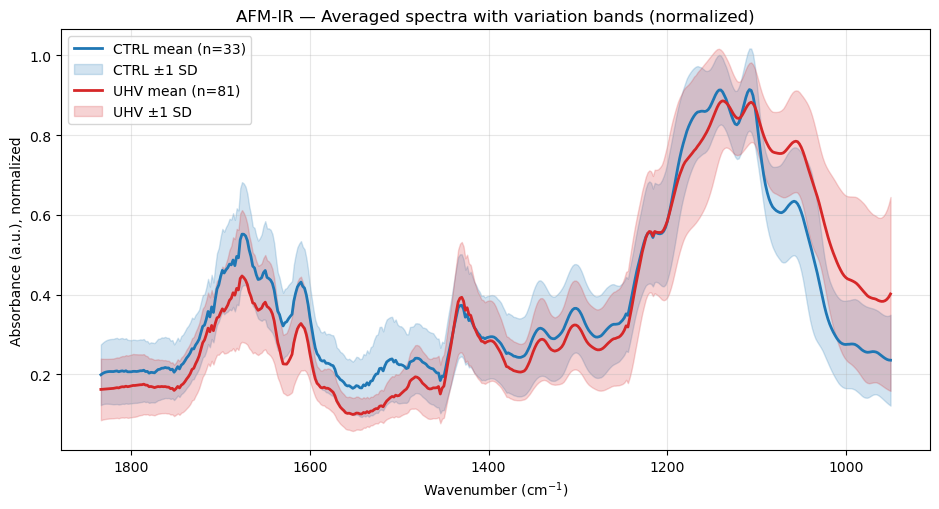

In [9]:
# === Averaging and variation bands on NORMALIZED spectra ===

# Source for averaging:
# - normalized_dfs  : averages after per-spectrum normalization
# - filtered_dfs    : averages on filtered (non-normalized) data
# - group_dfs       : averages on raw data
AVERAGING_SOURCE = "normalized"  # options: "normalized", "filtered", "raw"

if AVERAGING_SOURCE == "normalized":
    source = normalized_dfs
    avg_title_suffix = " (normalized)"
elif AVERAGING_SOURCE == "filtered":
    source = filtered_dfs
    avg_title_suffix = " (filtered)"
elif AVERAGING_SOURCE == "raw":
    source = group_dfs
    avg_title_suffix = " (raw)"
else:
    raise ValueError("AVERAGING_SOURCE must be one of: 'normalized', 'filtered', 'raw'.")

# Compute mean and variation at each wavenumber
stats = {}
for group, df in source.items():
    # Mean and SD across spectra at each wavenumber
    mu = df.mean(axis=1)
    sd = df.std(axis=1, ddof=1) if df.shape[1] > 1 else pd.Series(np.zeros(len(df)), index=df.index)
    stats[group] = {"mean": mu, "std": sd, "n": df.shape[1]}

# Plot both averages with ±1 SD shading
plt.figure(figsize=(9.5, 5.2))
colors = {"ctrl": "tab:blue", "uhv": "tab:red"}

for group in ["ctrl", "uhv"]:
    mu = stats[group]["mean"]
    sd = stats[group]["std"]
    n  = stats[group]["n"]
    x  = mu.index.values
    plt.plot(x, mu.values, color=colors[group], lw=2.0, label=f"{group.upper()} mean (n={n})")
    plt.fill_between(x, (mu - sd).values, (mu + sd).values, color=colors[group], alpha=0.20, label=f"{group.upper()} ±1 SD")

if INVERT_X_AXIS:
    plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel(Y_UNITS + (", normalized" if AVERAGING_SOURCE == "normalized" else ""))
plt.title(f"AFM-IR — Averaged spectra with variation bands{avg_title_suffix}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
